<a href="https://colab.research.google.com/github/srj1407/Data_Science_and_ML/blob/main/pytorch_model_deployment_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09. PyTorch Model Deployment Exercises

Welcome to the 09. PyTorch Model Deployment exercises.

Your objective is to write code to satisify each of the exercises below.

Some starter code has been provided to make sure you have all the resources you need.

> **Note:** There may be more than one solution to each of the exercises.

## Resources

1. These exercises/solutions are based on [section 09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/jOX5ZCkWO-0) (but try the exercises yourself first!).
3. See [all solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

> **Note:** The first section of this notebook is dedicated to getting various helper functions and datasets used for the exercises. The exercises start at the heading "Exercise 1: ...".

### Get various imports and helper functions

The code in the following cells prepares imports and data for the exercises below. They are taken from [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/).

In [1]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) > 1, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")


torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4400 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 19.79 MiB/s, done.
Resolving deltas: 100% (2661/2661), done.
Updating files: 100% (248/248), done.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Get data

Want to download the data we've been using in PyTorch Model Deployment: https://www.learnpytorch.io/09_pytorch_model_deployment/#1-getting-data

In [4]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi_20_percent.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip...
[INFO] Unzipping pizza_steak_sushi_20_percent.zip data...


PosixPath('data/pizza_steak_sushi')

In [5]:
# Setup directory paths to train and test images
train_dir = image_path / "train"
test_dir = image_path / "test"

### Preprocess data

Turn images into tensors using same code as PyTorch Paper Replicating section 2.1 and 2.2: https://www.learnpytorch.io/08_pytorch_paper_replicating/#21-prepare-transforms-for-images

In [6]:
# Create image size (from Table 3 in the ViT paper)
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [7]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7bebdf3f2e10>,
 ['pizza', 'steak', 'sushi'])

In [8]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(2))

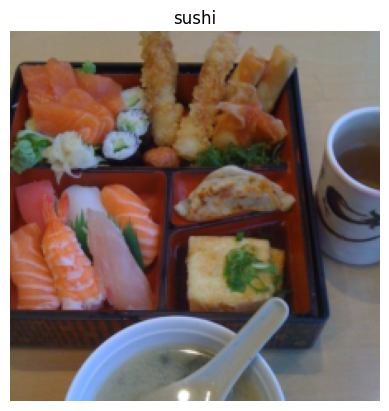

In [9]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

## Exercise 1. Make and time predictions with both feature extractor models on the test dataset using the GPU (`device="cuda"`).

* Compare the model's prediction times on GPU vs CPU - does this close the gap between them? As in, does making predictions on the GPU make the ViT feature extractor prediction times closer to the EffNetB2 feature extractor prediction times?
* You'll find code to do these steps in [section 5. Making predictions with our trained models and timing them](https://www.learnpytorch.io/09_pytorch_model_deployment/#5-making-predictions-with-our-trained-models-and-timing-them) and [section 6. Comparing model results, prediction times and size](https://www.learnpytorch.io/09_pytorch_model_deployment/#6-comparing-model-results-prediction-times-and-size).

In [10]:
# TODO: your code
train_dir = image_path / "train"
test_dir = image_path / "test"

In [11]:
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
pretrained_vit = torchvision.models.vit_b_16(weights = pretrained_vit_weights).to(device)
pretrained_vit_transforms = pretrained_vit_weights.transforms()

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 170MB/s]


In [18]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader_vit, test_dataloader_vit, class_names_vit = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=pretrained_vit_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

train_dataloader_vit, test_dataloader_vit, class_names_vit

(<torch.utils.data.dataloader.DataLoader at 0x7bebb5c5b530>,
 ['pizza', 'steak', 'sushi'])

In [13]:
for parameter in pretrained_vit.parameters():
  parameter.requires_grad = False

set_seeds()

pretrained_vit.heads = nn.Linear(in_features = 768, out_features = len(class_names)).to(device)

In [19]:
from going_modular.going_modular import engine

optimizer = torch.optim.Adam(params = pretrained_vit.parameters(),
                             lr = 1e-3)

loss_fn = torch.nn.CrossEntropyLoss()

set_seeds()

pretrained_vit_results = engine.train(model = pretrained_vit,
                                      train_dataloader = train_dataloader_vit,
                                      test_dataloader = test_dataloader_vit,
                                      optimizer = optimizer,
                                      loss_fn = loss_fn,
                                      epochs = 10,
                                      device = device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.1032 | train_acc: 0.9563 | test_loss: 0.0633 | test_acc: 0.9722
Epoch: 2 | train_loss: 0.0444 | train_acc: 0.9979 | test_loss: 0.0734 | test_acc: 0.9722
Epoch: 3 | train_loss: 0.0399 | train_acc: 1.0000 | test_loss: 0.0662 | test_acc: 0.9784
Epoch: 4 | train_loss: 0.0292 | train_acc: 1.0000 | test_loss: 0.0594 | test_acc: 0.9722
Epoch: 5 | train_loss: 0.0258 | train_acc: 1.0000 | test_loss: 0.0569 | test_acc: 0.9722
Epoch: 6 | train_loss: 0.0288 | train_acc: 1.0000 | test_loss: 0.0551 | test_acc: 0.9722
Epoch: 7 | train_loss: 0.0211 | train_acc: 1.0000 | test_loss: 0.0581 | test_acc: 0.9659
Epoch: 8 | train_loss: 0.0195 | train_acc: 1.0000 | test_loss: 0.0566 | test_acc: 0.9784
Epoch: 9 | train_loss: 0.0223 | train_acc: 1.0000 | test_loss: 0.0548 | test_acc: 0.9784
Epoch: 10 | train_loss: 0.0154 | train_acc: 1.0000 | test_loss: 0.0515 | test_acc: 0.9812


In [20]:
pretrained_effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
pretrained_effnetb2 = torchvision.models.efficientnet_b2(weights = pretrained_effnetb2_weights).to(device)
pretrained_effnetb2_transforms = pretrained_effnetb2_weights.transforms()

In [21]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader_effnetb2, test_dataloader_effnetb2, class_names_effnetb2 = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=pretrained_effnetb2_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

train_dataloader_effnetb2, test_dataloader_effnetb2, class_names_effnetb2

(<torch.utils.data.dataloader.DataLoader at 0x7bebc0506870>,
 ['pizza', 'steak', 'sushi'])

In [33]:
for parameter in pretrained_effnetb2.parameters():
  parameter.requires_grad = False

set_seeds()

pretrained_effnetb2.classifier = nn.Sequential(nn.Dropout(p = 0.3),
                                          nn.Linear(in_features = 1408, out_features = 3))

In [35]:
from going_modular.going_modular import engine

optimizer = torch.optim.Adam(params = pretrained_effnetb2.parameters(),
                             lr = 1e-3)

loss_fn = torch.nn.CrossEntropyLoss()

set_seeds()

pretrained_effnetb2_results = engine.train(model = pretrained_effnetb2,
                                      train_dataloader = train_dataloader_effnetb2,
                                      test_dataloader = test_dataloader_effnetb2,
                                      optimizer = optimizer,
                                      loss_fn = loss_fn,
                                      epochs = 10,
                                      device = device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9721 | train_acc: 0.5646 | test_loss: 0.7355 | test_acc: 0.9409
Epoch: 2 | train_loss: 0.7212 | train_acc: 0.8458 | test_loss: 0.5855 | test_acc: 0.9381
Epoch: 3 | train_loss: 0.5809 | train_acc: 0.8583 | test_loss: 0.4873 | test_acc: 0.9625
Epoch: 4 | train_loss: 0.4474 | train_acc: 0.9021 | test_loss: 0.4301 | test_acc: 0.9347
Epoch: 5 | train_loss: 0.4347 | train_acc: 0.8938 | test_loss: 0.3884 | test_acc: 0.9352
Epoch: 6 | train_loss: 0.4180 | train_acc: 0.8875 | test_loss: 0.3501 | test_acc: 0.9688
Epoch: 7 | train_loss: 0.4243 | train_acc: 0.8708 | test_loss: 0.3241 | test_acc: 0.9534
Epoch: 8 | train_loss: 0.3842 | train_acc: 0.8958 | test_loss: 0.3380 | test_acc: 0.9506
Epoch: 9 | train_loss: 0.3724 | train_acc: 0.8958 | test_loss: 0.3086 | test_acc: 0.9131
Epoch: 10 | train_loss: 0.3547 | train_acc: 0.8604 | test_loss: 0.2801 | test_acc: 0.9625


In [36]:
from pathlib import Path

# Get all test data paths
print(f"[INFO] Finding all filepaths ending with '.jpg' in directory: {test_dir}")
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))
test_data_paths[:5]

[INFO] Finding all filepaths ending with '.jpg' in directory: data/pizza_steak_sushi/test


[PosixPath('data/pizza_steak_sushi/test/steak/219196.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1972463.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/2061929.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/2756200.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/864661.jpg')]

In [37]:
import pathlib
import torch

from PIL import Image
from timeit import default_timer as timer
from tqdm.auto import tqdm
from typing import List, Dict

# 1. Create a function to return a list of dictionaries with sample, truth label, prediction, prediction probability and prediction time
def pred_and_store(paths: List[pathlib.Path],
                   model: torch.nn.Module,
                   transform: torchvision.transforms,
                   class_names: List[str],
                   device: str = "cuda" if torch.cuda.is_available() else "cpu") -> List[Dict]:

    # 2. Create an empty list to store prediction dictionaries
    pred_list = []

    # 3. Loop through target paths
    for path in tqdm(paths):

        # 4. Create empty dictionary to store prediction information for each sample
        pred_dict = {}

        # 5. Get the sample path and ground truth class name
        pred_dict["image_path"] = path
        class_name = path.parent.stem
        pred_dict["class_name"] = class_name

        # 6. Start the prediction timer
        start_time = timer()

        # 7. Open image path
        img = Image.open(path)

        # 8. Transform the image, add batch dimension and put image on target device
        transformed_image = transform(img).unsqueeze(0).to(device)

        # 9. Prepare model for inference by sending it to target device and turning on eval() mode
        model.to(device)
        model.eval()

        # 10. Get prediction probability, predicition label and prediction class
        with torch.inference_mode():
            pred_logit = model(transformed_image) # perform inference on target sample
            pred_prob = torch.softmax(pred_logit, dim=1) # turn logits into prediction probabilities
            pred_label = torch.argmax(pred_prob, dim=1) # turn prediction probabilities into prediction label
            pred_class = class_names[pred_label.cpu()] # hardcode prediction class to be on CPU

            # 11. Make sure things in the dictionary are on CPU (required for inspecting predictions later on)
            pred_dict["pred_prob"] = round(pred_prob.unsqueeze(0).max().cpu().item(), 4)
            pred_dict["pred_class"] = pred_class

            # 12. End the timer and calculate time per pred
            end_time = timer()
            pred_dict["time_for_pred"] = round(end_time-start_time, 4)

        # 13. Does the pred match the true label?
        pred_dict["correct"] = class_name == pred_class

        # 14. Add the dictionary to the list of preds
        pred_list.append(pred_dict)

    # 15. Return list of prediction dictionaries
    return pred_list

In [38]:
# Make predictions across test dataset with EffNetB2
vit_test_pred_dicts = pred_and_store(paths=test_data_paths,
                                          model=pretrained_vit,
                                          transform=pretrained_vit_transforms,
                                          class_names=class_names_vit,
                                          device="cuda")

  0%|          | 0/150 [00:00<?, ?it/s]

In [39]:
# Make predictions across test dataset with EffNetB2
effnetb2_test_pred_dicts = pred_and_store(paths=test_data_paths,
                                          model=pretrained_effnetb2,
                                          transform=pretrained_effnetb2_transforms,
                                          class_names=class_names_effnetb2,
                                          device="cuda")

  0%|          | 0/150 [00:00<?, ?it/s]

In [40]:
import pandas as pd
vit_test_pred_df = pd.DataFrame(vit_test_pred_dicts)
vit_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi/test/steak/219196.jpg,steak,0.9984,steak,0.0606,True
1,data/pizza_steak_sushi/test/steak/1972463.jpg,steak,0.9999,steak,0.0302,True
2,data/pizza_steak_sushi/test/steak/2061929.jpg,steak,0.9970,steak,0.0320,True
3,data/pizza_steak_sushi/test/steak/2756200.jpg,steak,0.9878,steak,0.0286,True
4,data/pizza_steak_sushi/test/steak/864661.jpg,steak,0.9953,steak,0.0276,True


In [41]:
effnetb2_test_pred_df = pd.DataFrame(effnetb2_test_pred_dicts)
effnetb2_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi/test/steak/219196.jpg,steak,0.9244,steak,0.1066,True
1,data/pizza_steak_sushi/test/steak/1972463.jpg,steak,0.7701,steak,0.0272,True
2,data/pizza_steak_sushi/test/steak/2061929.jpg,steak,0.9194,steak,0.0217,True
3,data/pizza_steak_sushi/test/steak/2756200.jpg,steak,0.9181,steak,0.0214,True
4,data/pizza_steak_sushi/test/steak/864661.jpg,steak,0.4053,steak,0.0207,True


In [44]:
vit_test_pred_df.correct.value_counts()

,count
correct,
True,147
False,3


In [45]:
# Find the average time per prediction
vit_average_time_per_pred = round(vit_test_pred_df.time_for_pred.mean(), 4)
print(f"vit average time per prediction: {vit_average_time_per_pred} seconds")

vit average time per prediction: 0.0225 seconds


In [42]:
effnetb2_test_pred_df.correct.value_counts()

,count
correct,
True,144
False,6


In [43]:
# Find the average time per prediction
effnetb2_average_time_per_pred = round(effnetb2_test_pred_df.time_for_pred.mean(), 4)
print(f"EffNetB2 average time per prediction: {effnetb2_average_time_per_pred} seconds")

EffNetB2 average time per prediction: 0.0232 seconds


## Exercise 2. The ViT feature extractor seems to have more learning capacity (due to more parameters) than EffNetB2, how does it go on the larger 20% split of the entire Food101 dataset?

* Train a ViT feature extractor on the 20% Food101 dataset for 5 epochs, just like we did with EffNetB2 in section [10. Creating FoodVision Big](https://www.learnpytorch.io/09_pytorch_model_deployment/#10-creating-foodvision-big).

In [ ]:
# TODO: your code

In [6]:
pretrained_101_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
pretrained_101_vit = torchvision.models.vit_b_16(weights = pretrained_101_vit_weights).to(device)
pretrained_101_vit_transforms = pretrained_101_vit_weights.transforms()

In [7]:
# Create Food101 training data transforms (only perform data augmentation on the training images)
food101_train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.TrivialAugmentWide(),
    pretrained_101_vit_transforms,
])

In [11]:
print(f"Training transforms:\n{food101_train_transforms}\n")
print(f"Testing transforms:\n{pretrained_101_vit_transforms}")

Training transforms:
Compose(
    TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
)

Testing transforms:
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [38]:
import torch
from datasets import load_dataset
from torchvision import transforms
from torch.utils.data import IterableDataset, DataLoader

# 1. Define your custom IterableDataset class
class FoodStreamingDataset(IterableDataset):
    def __init__(self, hf_subset, transform, total_samples):
        self.hf_subset = hf_subset
        self.transform = transform
        self.total_samples = total_samples

    def __iter__(self):
        for item in self.hf_subset:
            # Convert PIL image to RGB and apply transformations
            img = self.transform(item['image'].convert("RGB"))
            label = torch.tensor(item['label'])
            yield img, label

    def __len__(self):
        return self.total_samples

# 1. Open cloud streams for both splits
stream_train = load_dataset("ethz/food101", split="train", streaming=True)
stream_test = load_dataset("ethz/food101", split="validation", streaming=True)

# 2. Take exactly 20% of each split
# 20% of 75,750 = 15,150 | 20% of 25,250 = 5,050
subset_train = stream_train.take(15150)
subset_test = stream_test.take(5050)

# 2. Instantiate the dataset using your existing 'subset_train' and 'transform'
streaming_dataset_train = FoodStreamingDataset(subset_train, food101_train_transforms, total_samples=15150)
streaming_dataset_test = FoodStreamingDataset(subset_test, pretrained_101_vit_transforms, total_samples=5050)

train_dataloader_food101_20_percent = DataLoader(streaming_dataset_train, batch_size=32, num_workers=0)
test_dataloader_food101_20_percent = DataLoader(streaming_dataset_test, batch_size=32, num_workers=0)


In [39]:
for parameter in pretrained_101_vit.parameters():
  parameter.requires_grad = False

set_seeds()

pretrained_101_vit.heads = nn.Linear(in_features = 768, out_features = 101).to(device)

In [40]:
from torchinfo import summary

# Get a summary of EffNetB2 feature extractor for Food101 with 101 output classes (uncomment for full output)
summary(pretrained_101_vit,
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 101]             768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

In [41]:
from going_modular.going_modular import engine

# Setup optimizer
optimizer = torch.optim.Adam(params=pretrained_101_vit.parameters(),
                             lr=1e-3)

# Setup loss function
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1) # throw in a little label smoothing because so many classes

# Want to beat original Food101 paper with 20% of data, need 56.4%+ acc on test dataset
set_seeds()
effnetb2_food101_results = engine.train(model=pretrained_101_vit,
                                        train_dataloader=train_dataloader_food101_20_percent,
                                        test_dataloader=test_dataloader_food101_20_percent,
                                        optimizer=optimizer,
                                        loss_fn=loss_fn,
                                        epochs=5,
                                        device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch: 1 | train_loss: 2.7359 | train_acc: 0.5622 | test_loss: 4.9654 | test_acc: 0.3054
Epoch: 2 | train_loss: 1.9430 | train_acc: 0.6963 | test_loss: 2.8165 | test_acc: 0.4613
Epoch: 3 | train_loss: 1.6594 | train_acc: 0.7660 | test_loss: 2.4852 | test_acc: 0.5179
Epoch: 4 | train_loss: 1.5910 | train_acc: 0.7974 | test_loss: 2.3630 | test_acc: 0.5425
Epoch: 5 | train_loss: 1.5608 | train_acc: 0.8094 | test_loss: 2.3184 | test_acc: 0.5539


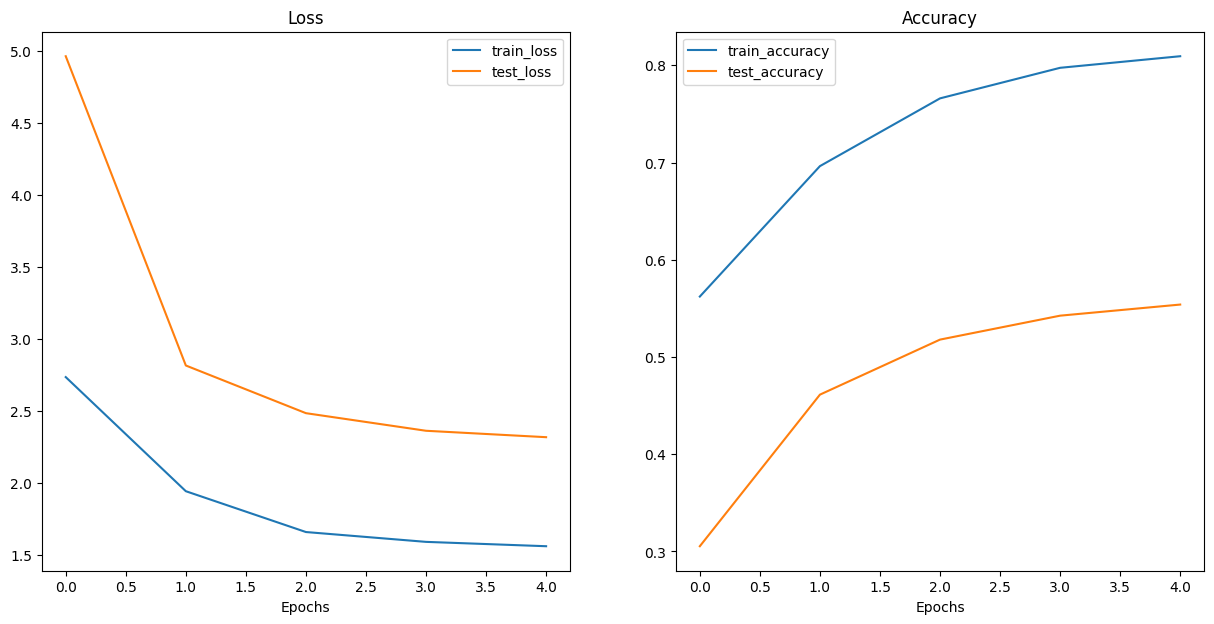

In [42]:
from helper_functions import plot_loss_curves

# Check out the loss curves for FoodVision Big
plot_loss_curves(effnetb2_food101_results)

## Exercise 3. Make predictions across the 20% Food101 test dataset with the ViT feature extractor from exercise 2 and find the "most wrong" predictions
* The predictions will be the ones with the highest prediction probability but with the wrong predicted label.
* Write a sentence or two about why you think the model got these predictions wrong.

In [ ]:
# TODO: your code

## Exercise 4. Evaluate the ViT feature extractor across the whole Food101 test dataset rather than just the 20% version, how does it perform?
* Does it beat the original Food101 paper's best result of 56.4% accuracy?

In [ ]:
# TODO: your code

## Exercise 5. Head to [Paperswithcode.com](https://paperswithcode.com/) and find the current best performing model on the Food101 dataset.
* What model architecture does it use?

In [ ]:
# TODO: your answer to the above

## Exercise 6. Write down 1-3 potential failure points of our deployed FoodVision models and what some potential solutions might be.
* For example, what happens if someone was to upload a photo that wasn't of food to our FoodVision Mini model?

In [ ]:
# TODO: your answer to the above

## Exercise 7. Pick any dataset from [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) and train a feature extractor model on it using a model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) (you could use one of the model's we've already created, e.g. EffNetB2 or ViT) for 5 epochs and then deploy your model as a Gradio app to Hugging Face Spaces.
* You may want to pick smaller dataset/make a smaller split of it so training doesn't take too long.
* I'd love to see your deployed models! So be sure to share them in Discord or on the [course GitHub Discussions page](https://github.com/mrdbourke/pytorch-deep-learning/discussions).

In [ ]:
# TODO: your code